In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import GcStar
from src.dataload import *
from src.dataPreProcessing import replace_nan


# Remove null values df. dropna(inplace=True)

# if variables are changed on the fly 
# from reloading import reloading
from tqdm.notebook import tqdm


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sadiqadedayo/miniforge3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sadiqadedayo/miniforge3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sadiqadedayo/miniforge3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.sta

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(2, 4)), 1, 1000

In [4]:
def make_GT(name):
    start = name.find('.')
    gt_name = name[:start] + '_gt_processed.csv'
    dat = load_data(name)
    data = dat['ts'].T
    n = data.shape[0]

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

names[0][:names[0].find('.')].replace('timeseries', '')

In [5]:
%%time

# load data
os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.mat')]
INFs = {}
CONF_MTX = {}
SHDs = {}
for i in range(len(names)):
    
    A = make_GT(names[i])
    X_ = load_data(names[i])
    X = X_['ts'].T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    
    # Analysis
    infs = []
    conf_mtx = []
    shds = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0, beta=0, simulation=False)   # 
        infs.append(inf)
        conf = gcstar.compute_confusion_matrix(A)
        conf_mtx.append(conf)
        shd = gcstar.compute_shd_sid(A, inf)
        shds.append(shd)
    INFs[names[i]] = infs
    CONF_MTX[names[i]] = conf_mtx
    SHDs[names[i]] = shds
    print('')
    print('')

Data sim19.mat with len = 120000

2 pasts
3 pasts


Data sim25.mat with len = 5000

2 pasts
3 pasts


Data sim24.mat with len = 10000

2 pasts
3 pasts


Data sim18.mat with len = 10000

2 pasts
3 pasts


Data sim26.mat with len = 2500

2 pasts
3 pasts


Data sim9.mat with len = 250000

2 pasts
3 pasts


Data sim8.mat with len = 10000

2 pasts
3 pasts


Data sim27.mat with len = 2500

2 pasts
3 pasts


Data sim23.mat with len = 10000

2 pasts
3 pasts


Data sim22.mat with len = 10000

2 pasts
3 pasts


Data sim20.mat with len = 120000

2 pasts
3 pasts


Data sim21.mat with len = 10000

2 pasts
3 pasts


Data sim10.mat with len = 10000

2 pasts
3 pasts


Data sim3.mat with len = 10000

2 pasts
3 pasts


Data sim2.mat with len = 10000

2 pasts
3 pasts


Data sim11.mat with len = 10000

2 pasts
3 pasts


Data sim13.mat with len = 10000

2 pasts
3 pasts


Data sim1.mat with len = 10000

2 pasts
3 pasts


Data sim12.mat with len = 10000

2 pasts
3 pasts


Data sim16.mat with len = 10000

2 p

In [6]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FP_inf],
                     [FN_inf,TN_inf]])


def apr_metrics(confusion_matrix):
    confusion_matrix = confusion_matrix.flatten()
    accuracy = (confusion_matrix[0] + confusion_matrix[3])/(np.sum(confusion_matrix))
    precision = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[1])
    recall = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[2])
    FPR = confusion_matrix[1]/(confusion_matrix[1]+confusion_matrix[3])
    return np.array([accuracy, precision, recall, FPR])

In [7]:
METRICs = {}
for keys in CONF_MTX:
    metrics = []
    for j in range(2):
        metrics.append(apr_metrics(CONF_MTX[keys][j]))        
    METRICs[keys] = metrics

In [8]:
METRICs

{'sim19.mat': [array([0.48      , 0.43478261, 1.        , 0.86666667]),
  array([0.4, 0.4, 1. , 1. ])],
 'sim25.mat': [array([0.76 , 0.625, 1.   , 0.4  ]),
  array([0.76 , 0.625, 1.   , 0.4  ])],
 'sim24.mat': [array([0.4, 0.4, 1. , 1. ]), array([0.4, 0.4, 1. , 1. ])],
 'sim18.mat': [array([0.76 , 0.625, 1.   , 0.4  ]),
  array([0.72      , 0.58823529, 1.        , 0.46666667])],
 'sim26.mat': [array([0.72      , 0.58823529, 1.        , 0.46666667]),
  array([0.68      , 0.55555556, 1.        , 0.53333333])],
 'sim9.mat': [array([0.4, 0.4, 1. , 1. ]), array([0.4, 0.4, 1. , 1. ])],
 'sim8.mat': [array([0.48      , 0.43478261, 1.        , 0.86666667]),
  array([0.48      , 0.43478261, 1.        , 0.86666667])],
 'sim27.mat': [array([0.76 , 0.625, 1.   , 0.4  ]),
  array([0.8       , 0.66666667, 1.        , 0.33333333])],
 'sim23.mat': [array([0.4, 0.4, 1. , 1. ]), array([0.4, 0.4, 1. , 1. ])],
 'sim22.mat': [array([0.6       , 0.5       , 1.        , 0.66666667]),
  array([0.56      , 0.4

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


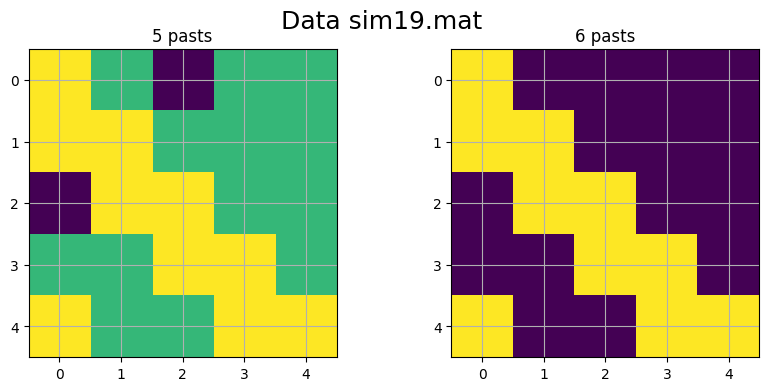

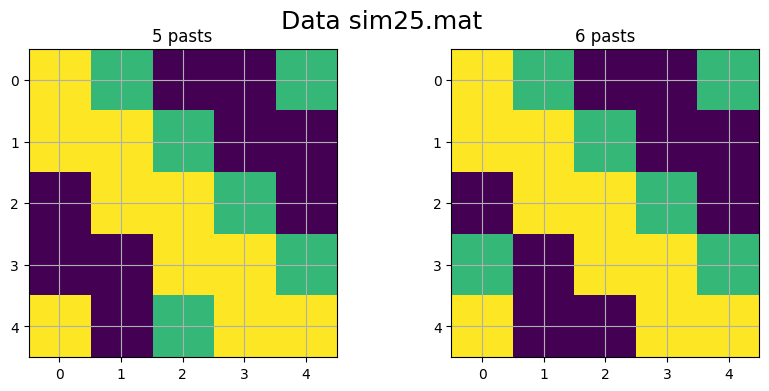

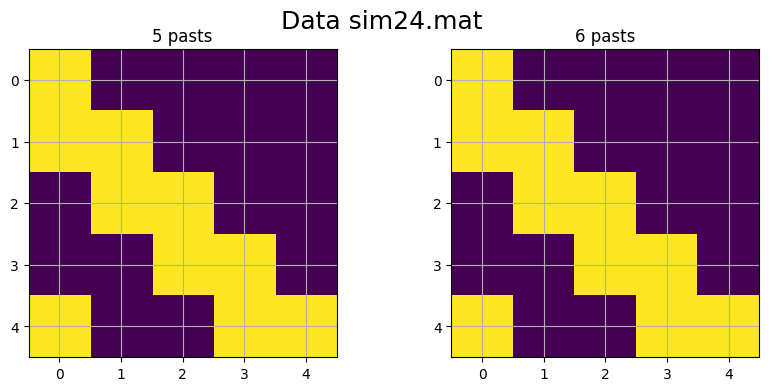

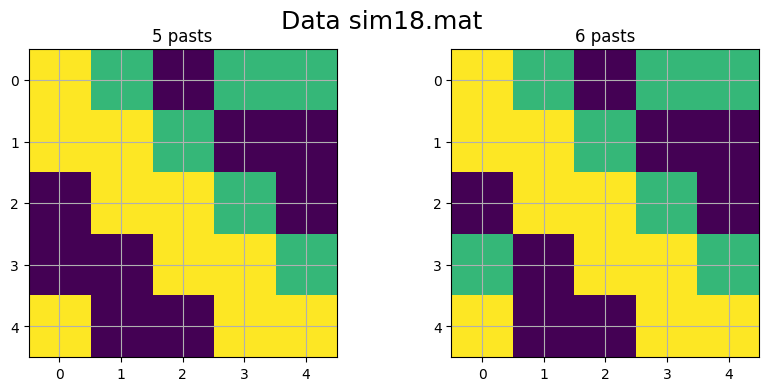

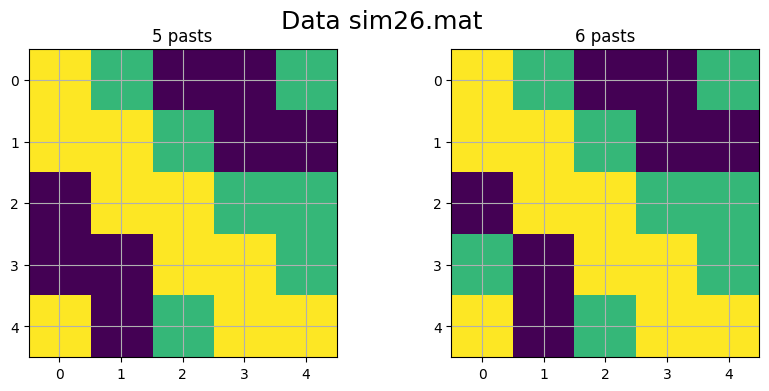

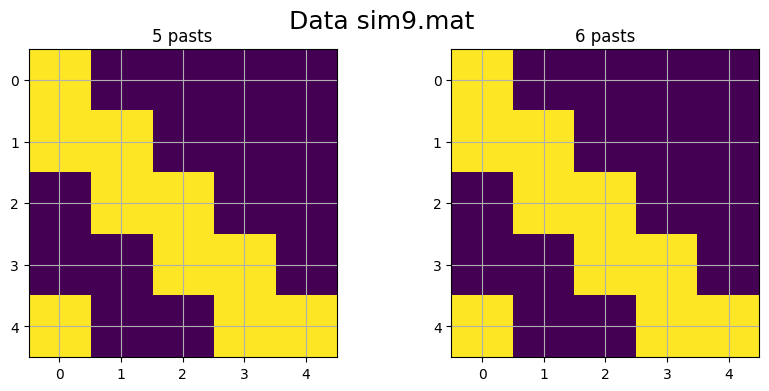

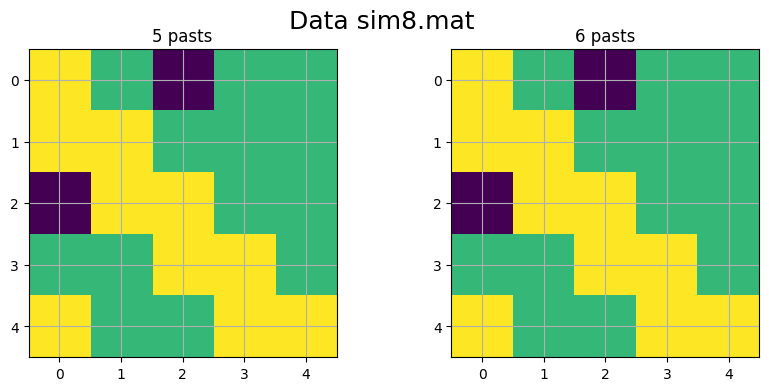

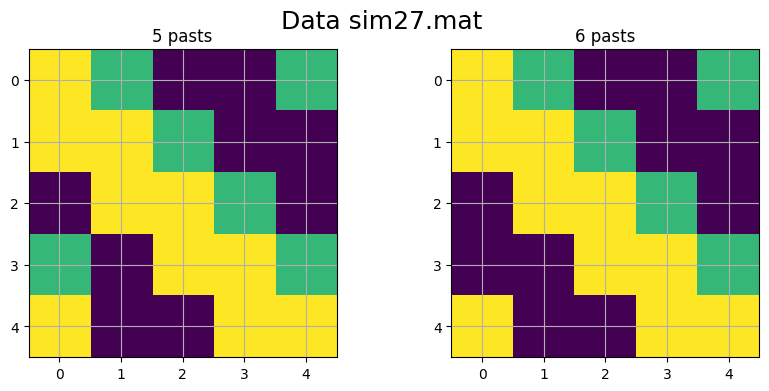

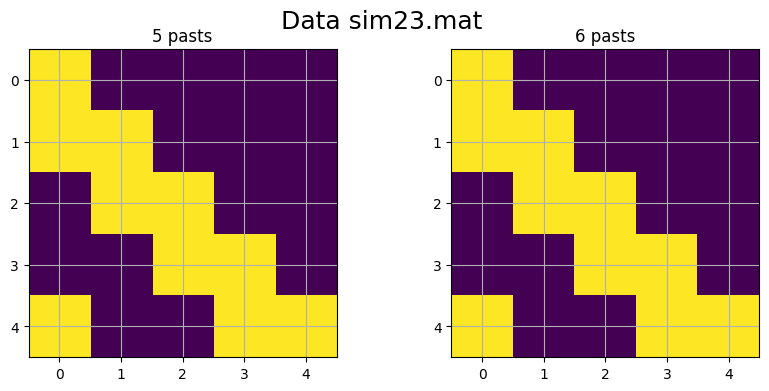

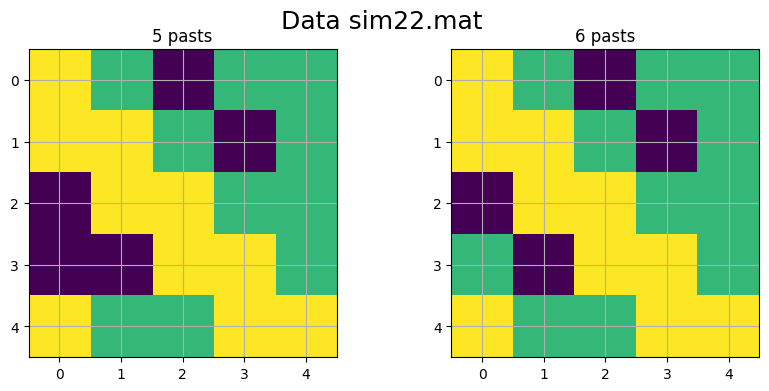

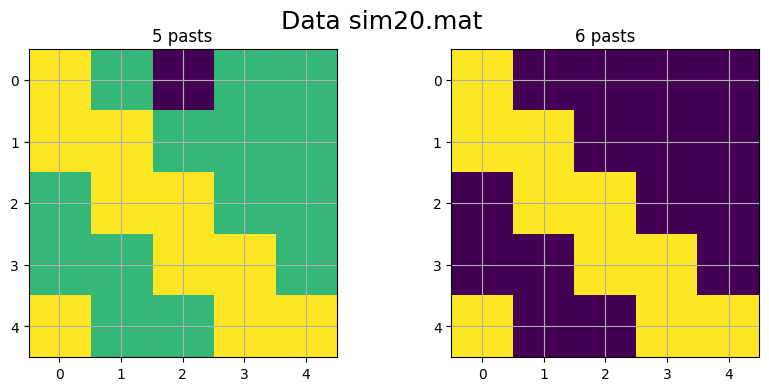

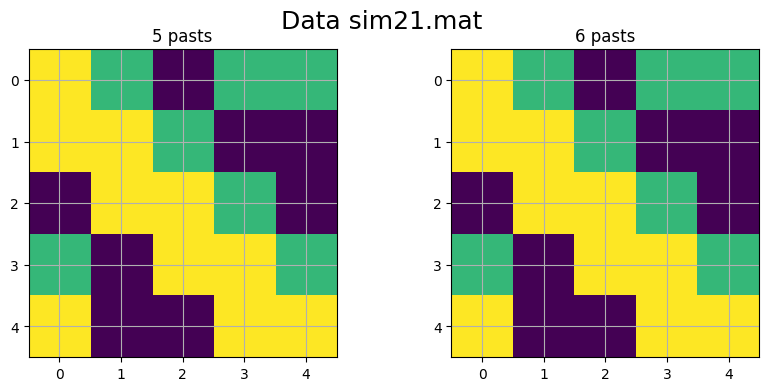

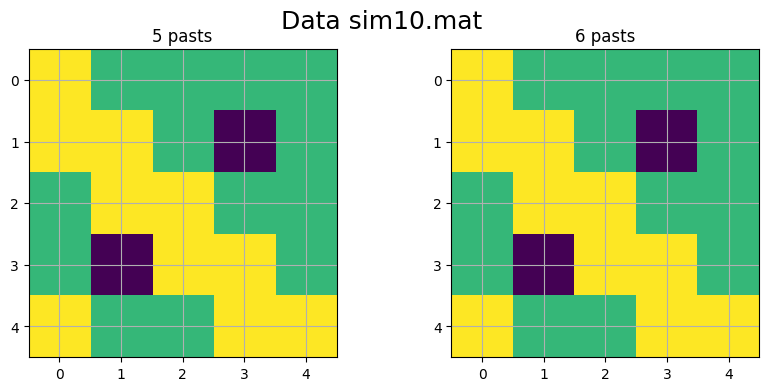

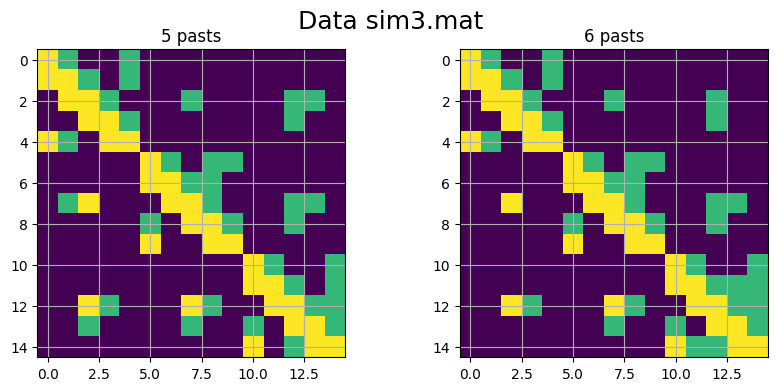

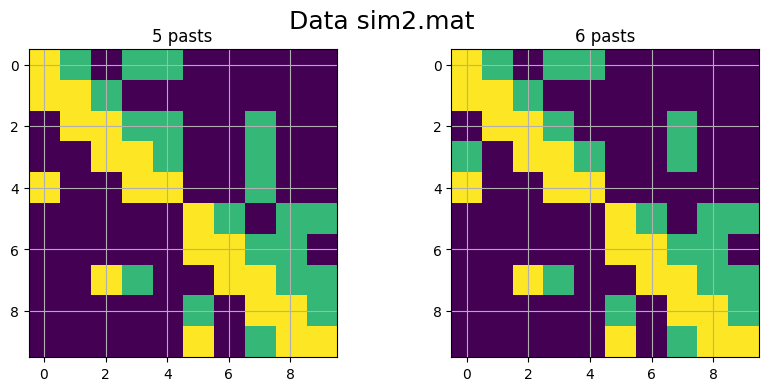

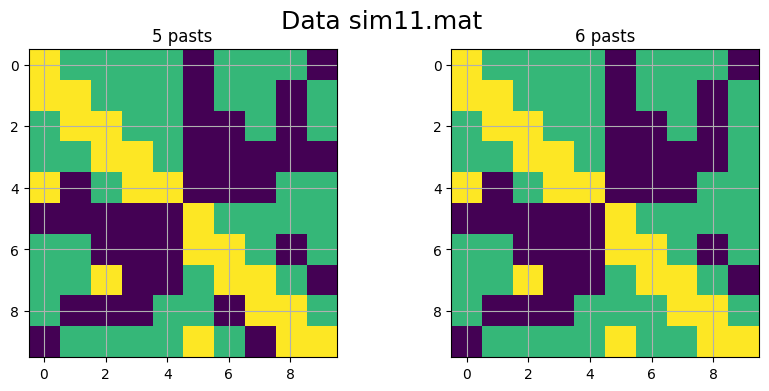

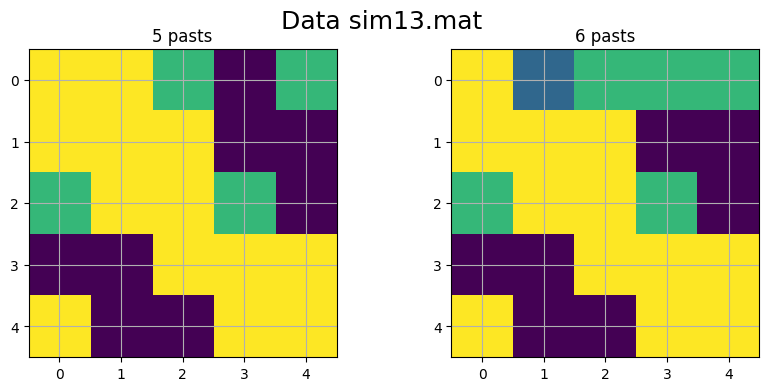

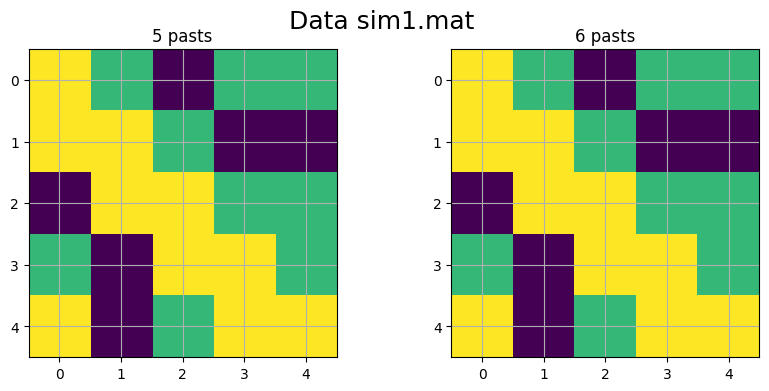

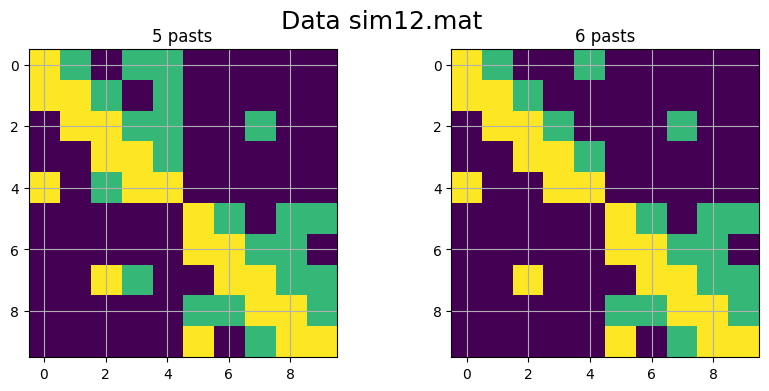

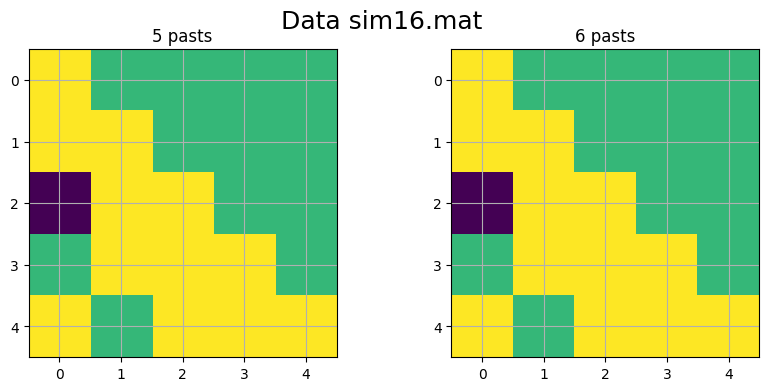

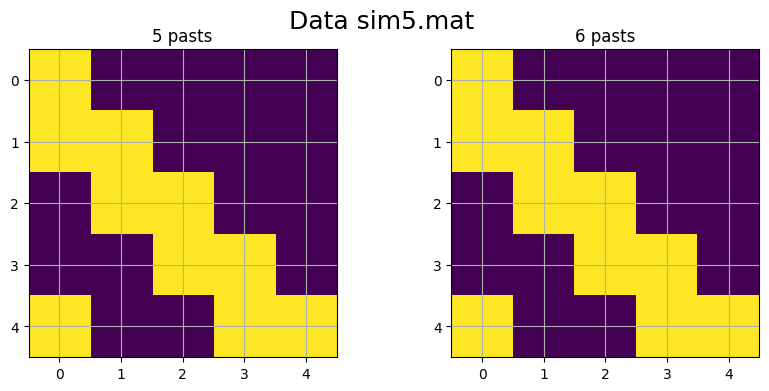

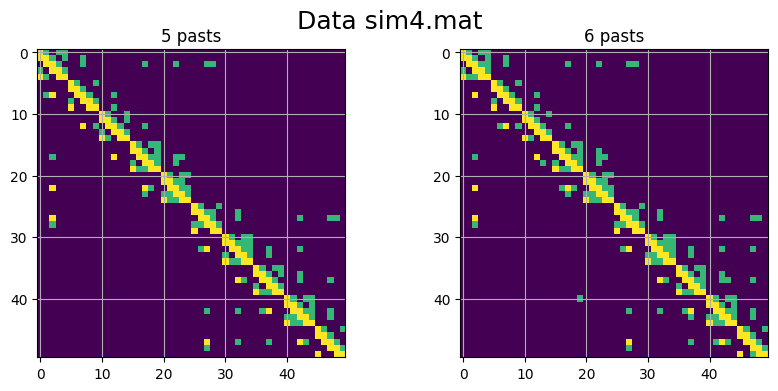

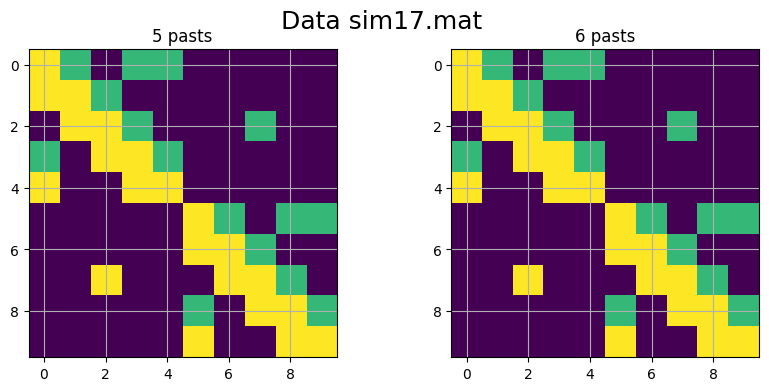

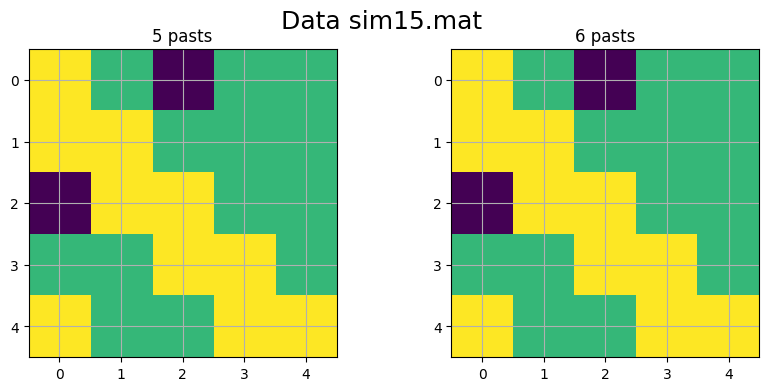

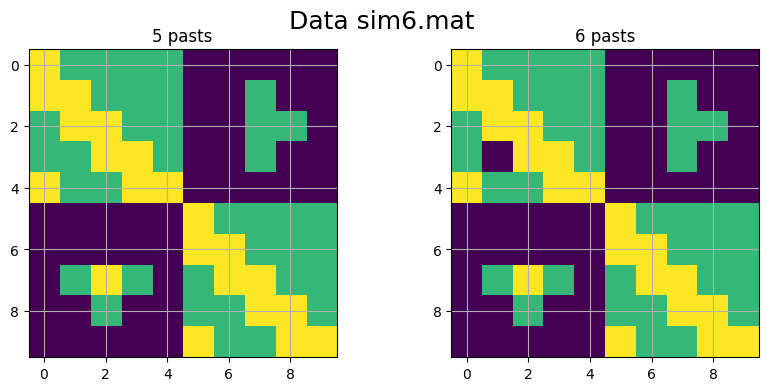

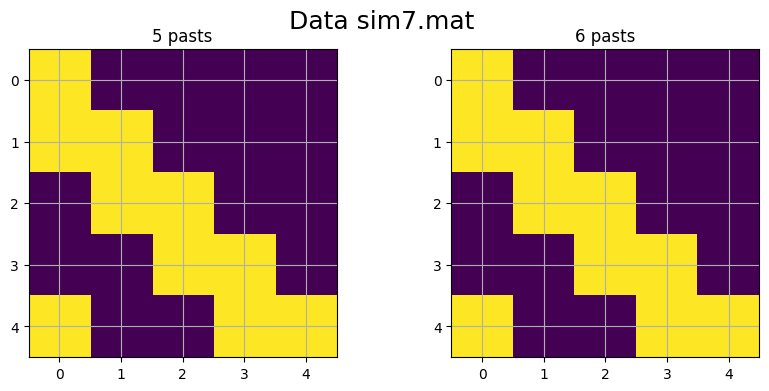

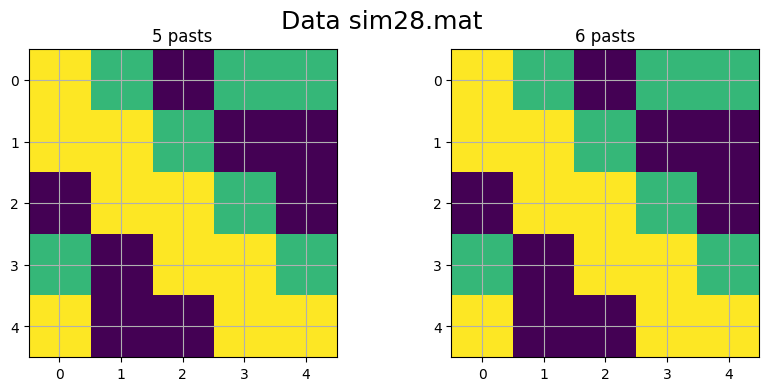

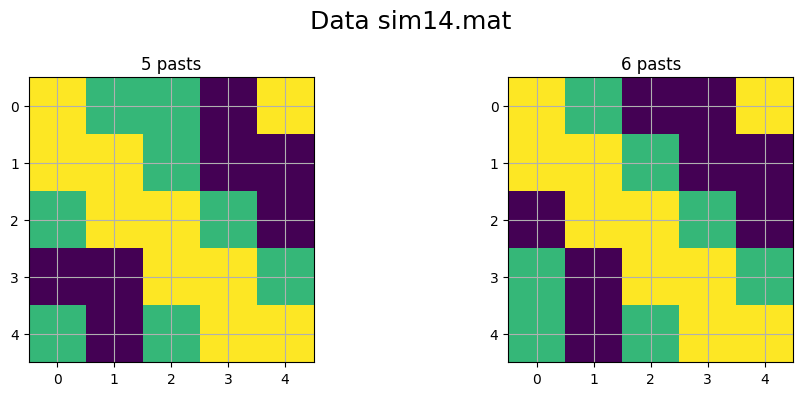

In [9]:
for i in range(28):
  A = make_GT(names[i])
  fig,ax = plt.subplots(1,2,figsize=(10,4))
  for j in range(2):
    ax[j].imshow(mat_func(A.T, INFs[names[i]][j]))
    ax[j].set_title(f'{j+5} pasts')
#     ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_xticklabels(pro,rotation=90)
#     ax[j].set_yticklabels(pro)
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
  # print('')
  # print('')
plt.tight_layout()

In [10]:
SHDs

{'sim19.mat': [np.float64(6.181155050942965), np.float64(6.453250173810225)],
 'sim25.mat': [np.float64(5.182769731453004), np.float64(5.065961217003332)],
 'sim24.mat': [np.float64(13.668236366142139), np.float64(13.668224485034994)],
 'sim18.mat': [np.float64(5.047703825408623), np.float64(5.095388553636101)],
 'sim26.mat': [np.float64(5.462044160151149), np.float64(5.526050749756195)],
 'sim9.mat': [np.float64(7.726188578571313), np.float64(7.726189810264842)],
 'sim8.mat': [np.float64(7.2451036396990585), np.float64(7.2449672957439635)],
 'sim27.mat': [np.float64(5.084054916770979), np.float64(5.0)],
 'sim23.mat': [np.float64(12.854803488770584), np.float64(12.85478172071885)],
 'sim22.mat': [np.float64(5.7809616416304745), np.float64(5.826070138543514)],
 'sim20.mat': [np.float64(6.407004817502379), np.float64(6.554803012750346)],
 'sim21.mat': [np.float64(5.101476068252833), np.float64(5.101433537830445)],
 'sim10.mat': [np.float64(7.375208422864053), np.float64(7.375164902134441

# On timeseries datas

In [11]:
def make_GT(name):
    dat = pd.read_csv(name,header=0)   # load_data(name)
    data = dat.values.T # dat['ts'].T
    n = data.shape[0]
    
    gt_name = 'sim' + names[i][:names[i].find('.')].replace('timeseries', '') + '_gt_processed.csv'
    #start = name.find('.')
    #gt_name =          #name[:start] + '_gt_processed.csv'
    

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

In [12]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.csv') and '_gt_' not in n]
INFs_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.01, beta=0.001, simulation=True)   # 
        infs.append(inf)
        #conf = gcstar.compute_confusion_matrix(A)
        #conf_mtx.append(conf)
        
    INFs_new[names[i]] = infs
    #CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

Data timeseries22.csv with len = 200

2 pasts
3 pasts


Data timeseries23.csv with len = 200

2 pasts
3 pasts


Data timeseries21.csv with len = 200

2 pasts
3 pasts


Data timeseries9.csv with len = 5000

2 pasts
3 pasts


Data timeseries8.csv with len = 200

2 pasts
3 pasts


Data timeseries20.csv with len = 2400

2 pasts
3 pasts


Data timeseries24.csv with len = 200

2 pasts
3 pasts


Data timeseries18.csv with len = 200

2 pasts
3 pasts


Data timeseries19.csv with len = 2400

2 pasts
3 pasts


Data timeseries25.csv with len = 100

2 pasts
3 pasts


Data timeseries27.csv with len = 50

2 pasts
3 pasts


Data timeseries26.csv with len = 50

2 pasts
3 pasts


Data timeseries17.csv with len = 200

2 pasts
3 pasts


Data timeseries3.csv with len = 200

2 pasts
3 pasts


Data timeseries2.csv with len = 200

2 pasts
3 pasts


Data timeseries16.csv with len = 200

2 pasts
3 pasts


Data timeseries28.csv with len = 100

2 pasts
3 pasts


Data timeseries14.csv with len = 200

2 pasts
3 pas

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


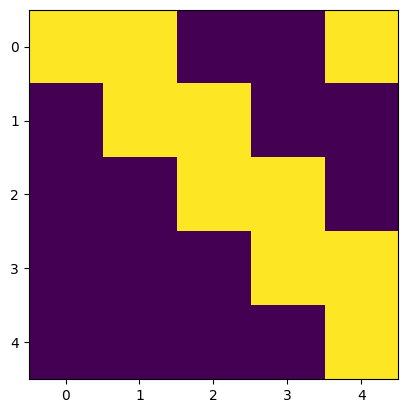

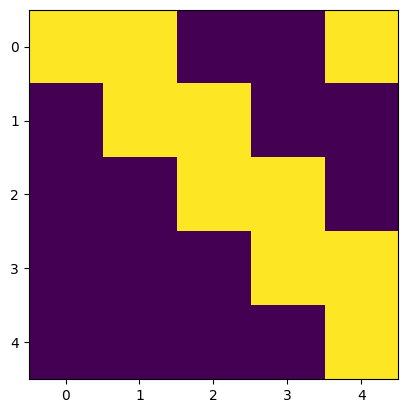

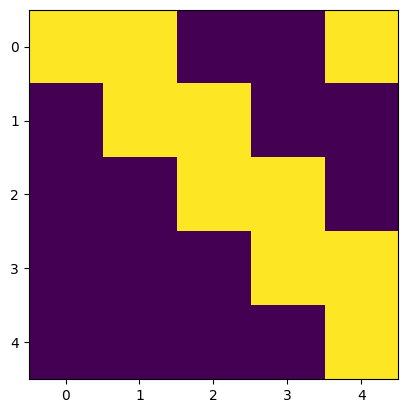

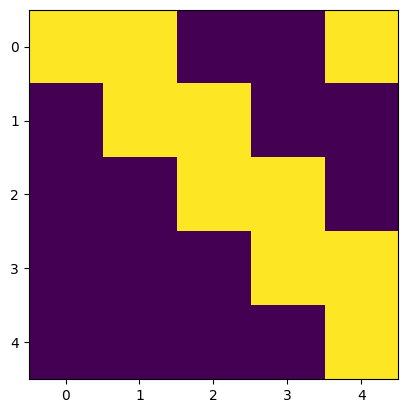

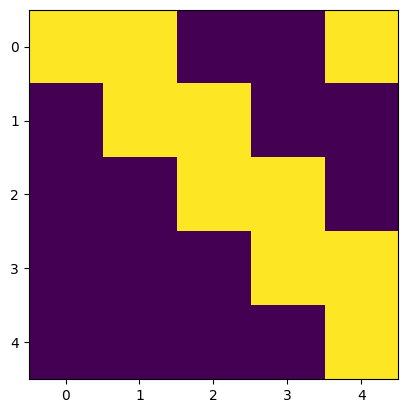

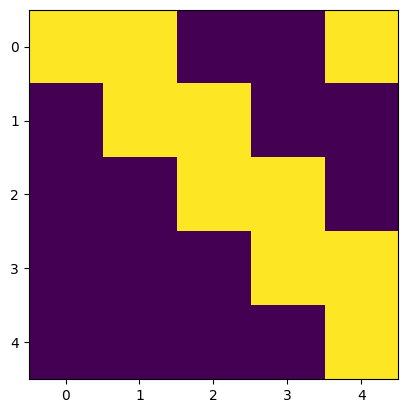

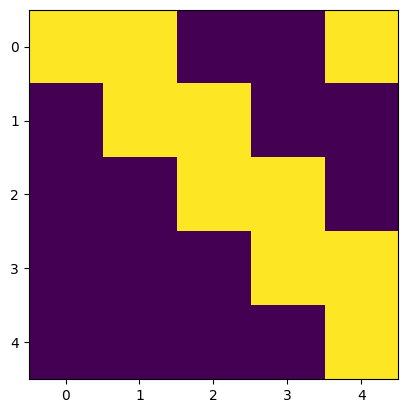

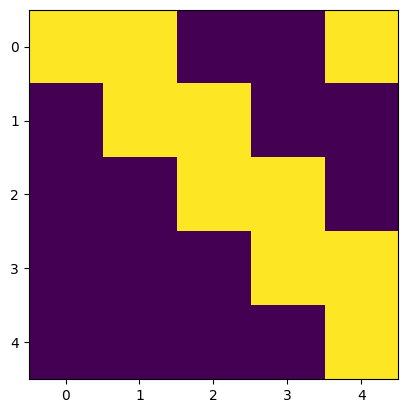

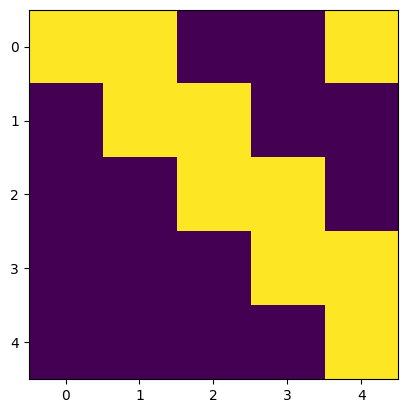

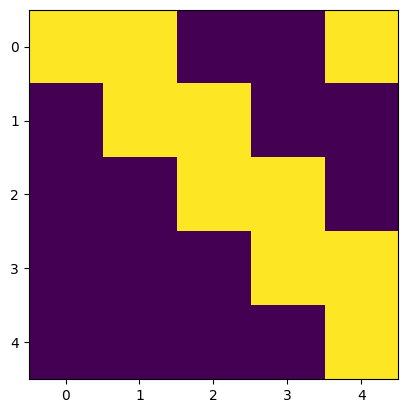

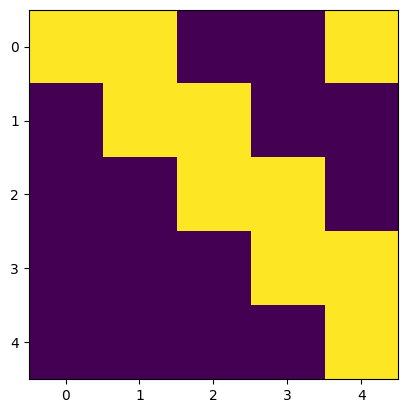

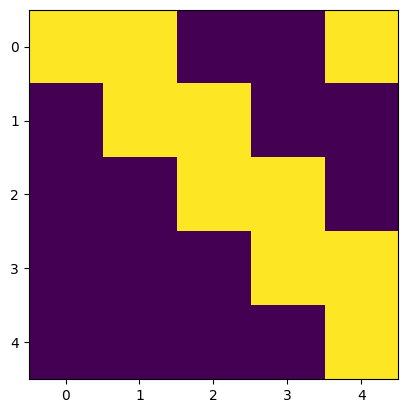

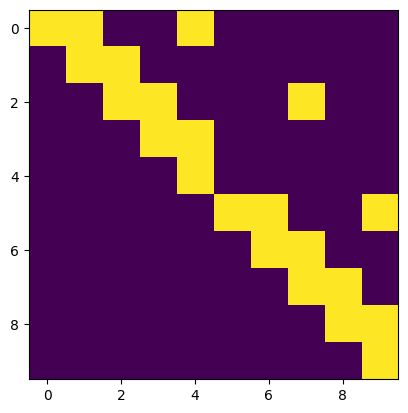

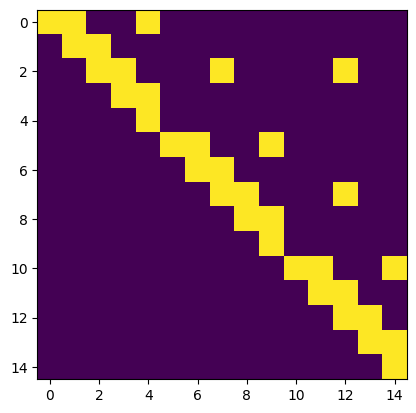

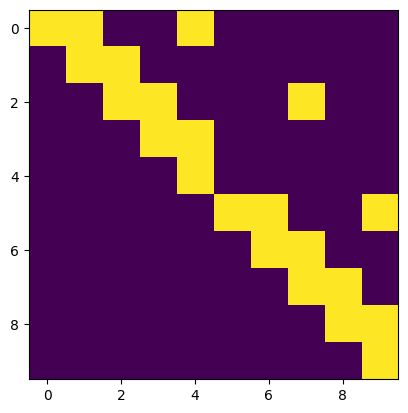

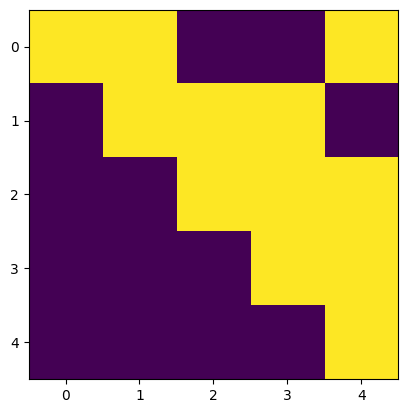

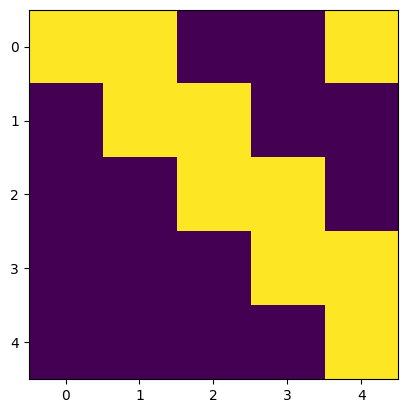

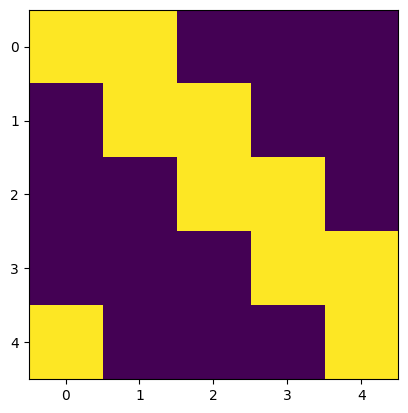

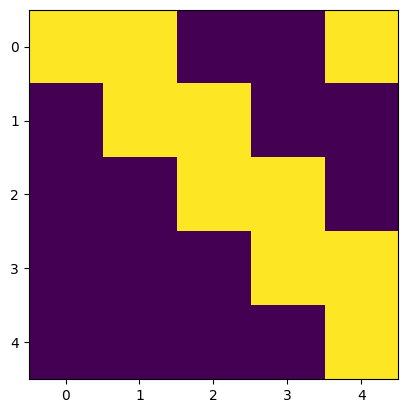

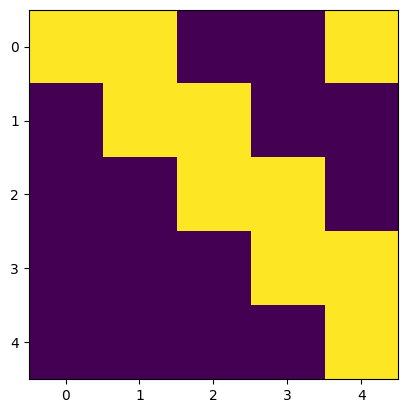

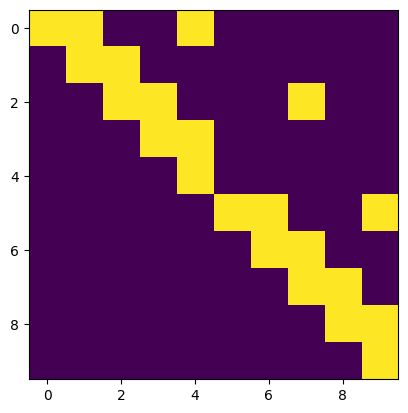

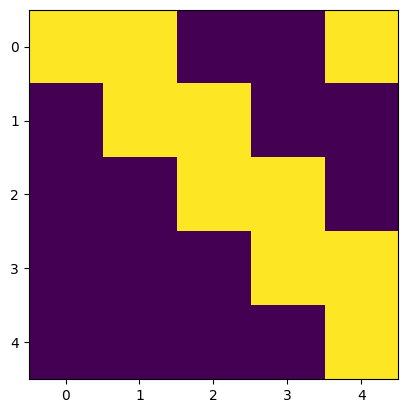

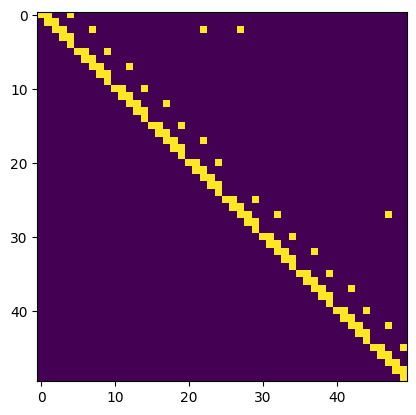

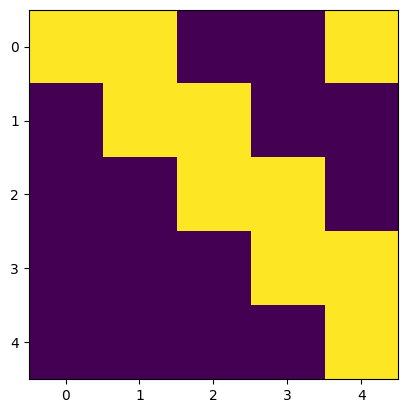

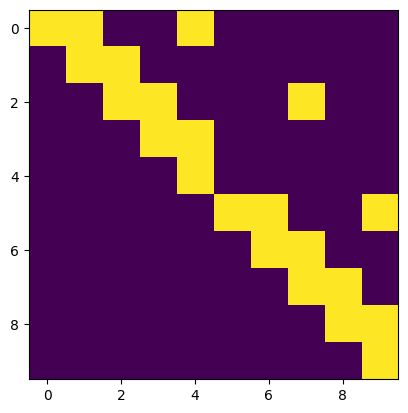

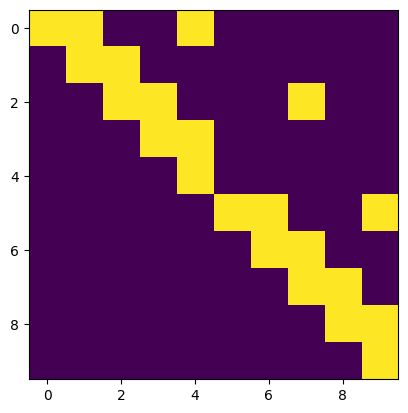

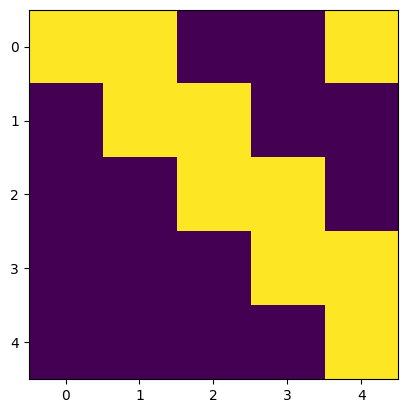

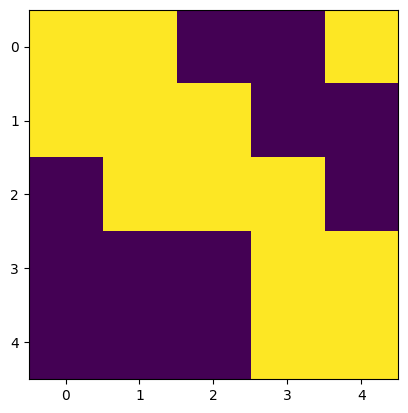

In [13]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [14]:
print(INFs_new.keys())

dict_keys(['timeseries22.csv', 'timeseries23.csv', 'timeseries21.csv', 'timeseries9.csv', 'timeseries8.csv', 'timeseries20.csv', 'timeseries24.csv', 'timeseries18.csv', 'timeseries19.csv', 'timeseries25.csv', 'timeseries27.csv', 'timeseries26.csv', 'timeseries17.csv', 'timeseries3.csv', 'timeseries2.csv', 'timeseries16.csv', 'timeseries28.csv', 'timeseries14.csv', 'timeseries1.csv', 'timeseries15.csv', 'timeseries11.csv', 'timeseries5.csv', 'timeseries4.csv', 'timeseries10.csv', 'timeseries12.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries13.csv'])


In [15]:
INFs_new

{'timeseries22.csv': [array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]]),
  array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]])],
 'timeseries23.csv': [array([[1.        , 0.        , 0.        , 0.        , 0.        ],
         [0.        , 1.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 1.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 1.        , 0.86795732],
         [0.        , 0.        , 0.        , 0.        , 0.        ]]),
  array([[1.       , 0.       , 0.       , 0.       , 0.       ],
         [0.       , 1.       , 0.       , 0.       , 0.       ],
         [0.       , 0.       , 1.       , 0.       , 0.       ],
         [0.       , 0.       , 0.       , 1.       , 0.8683102],
         [0.       , 0. 

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


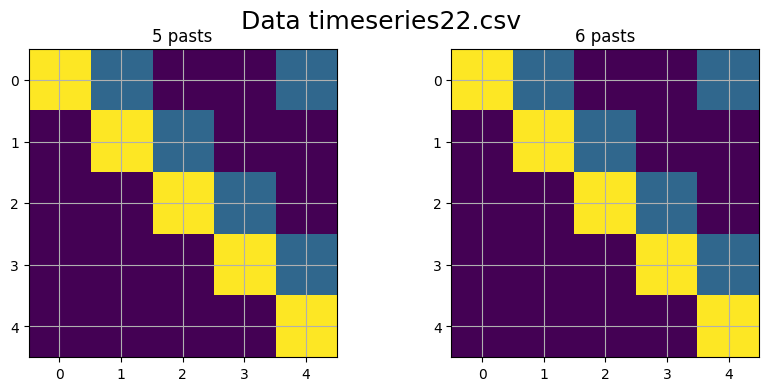

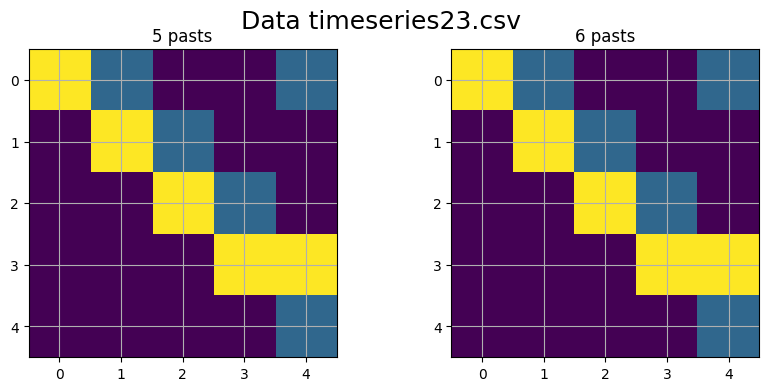

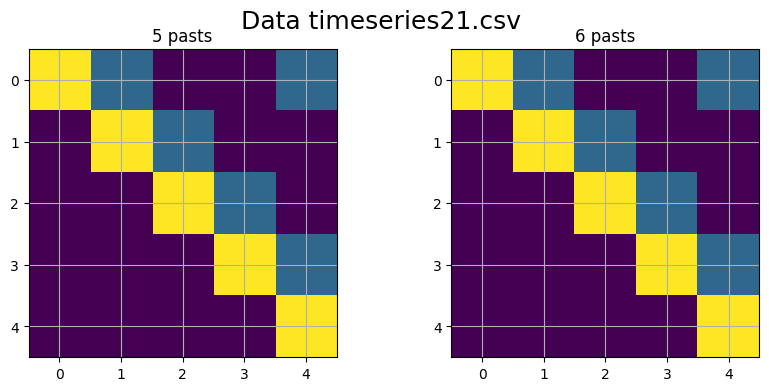

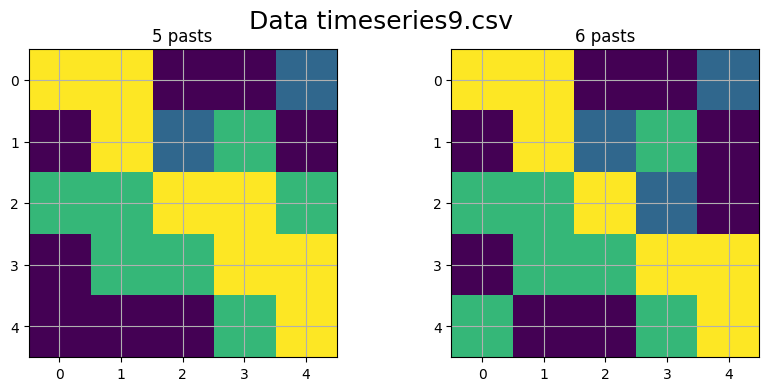

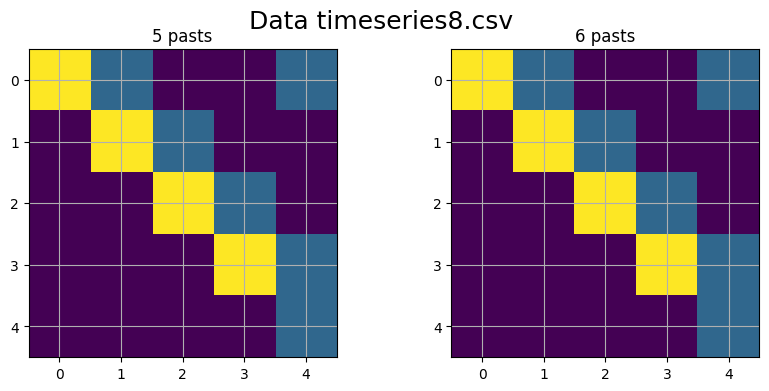

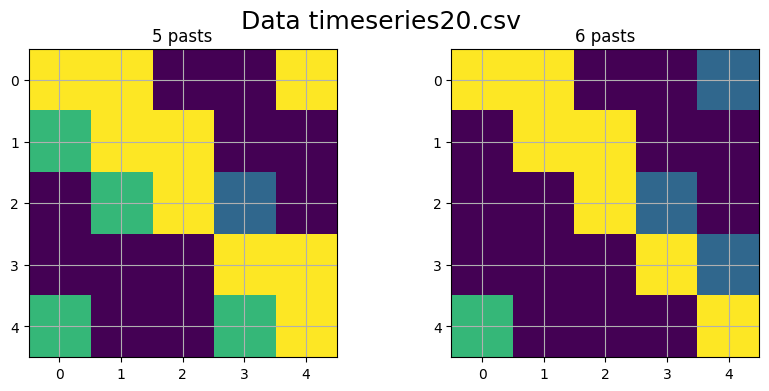

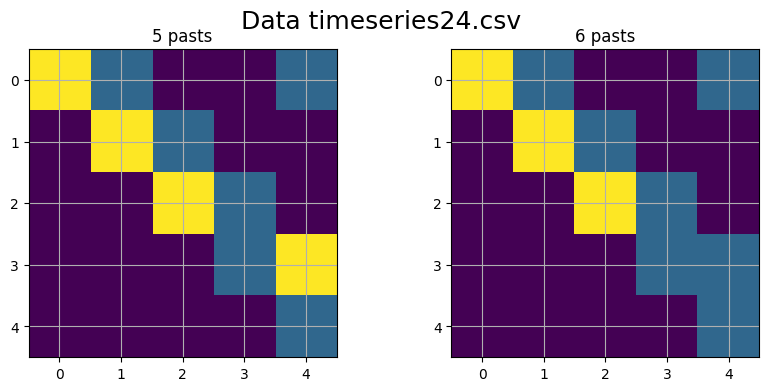

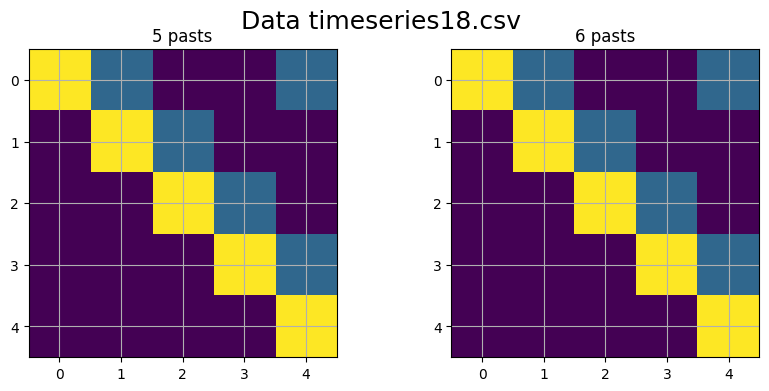

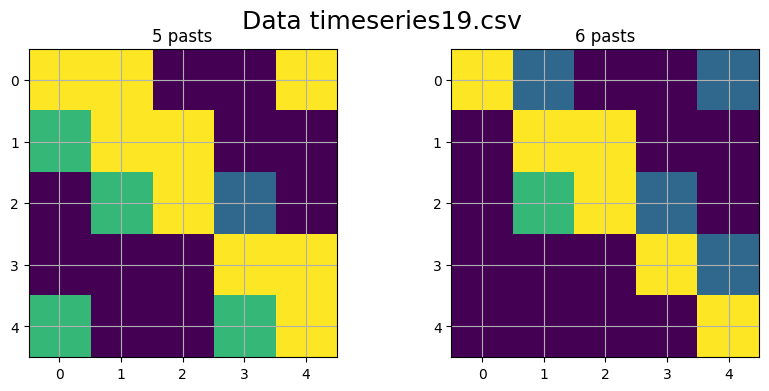

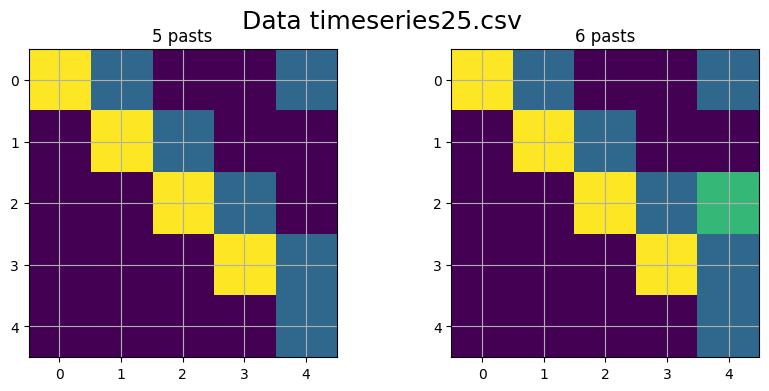

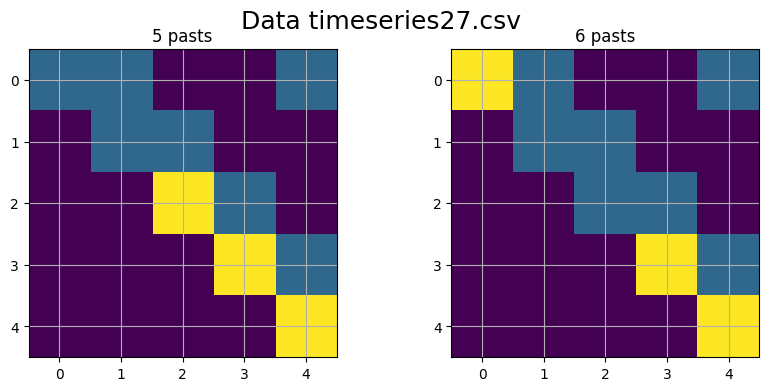

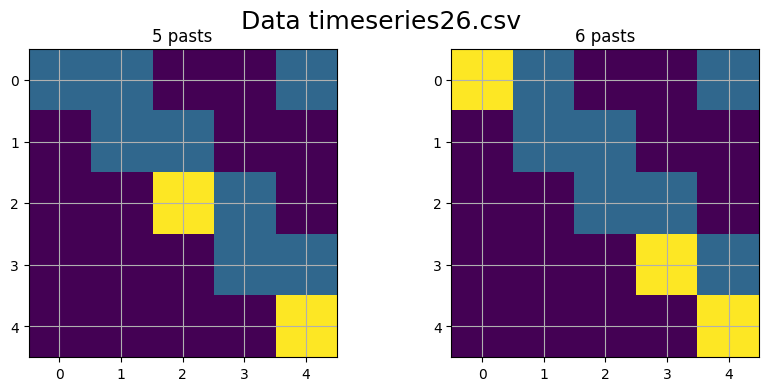

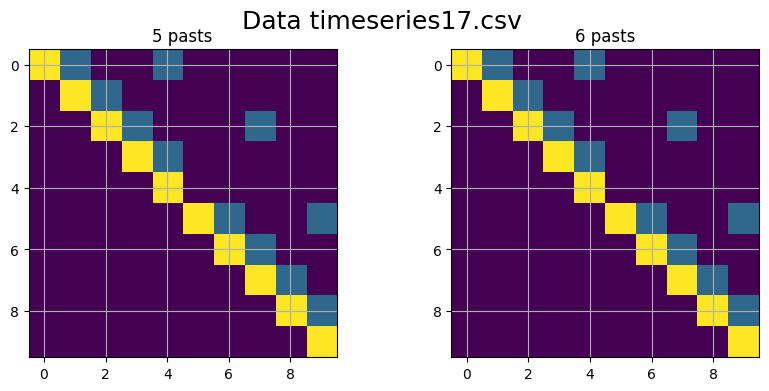

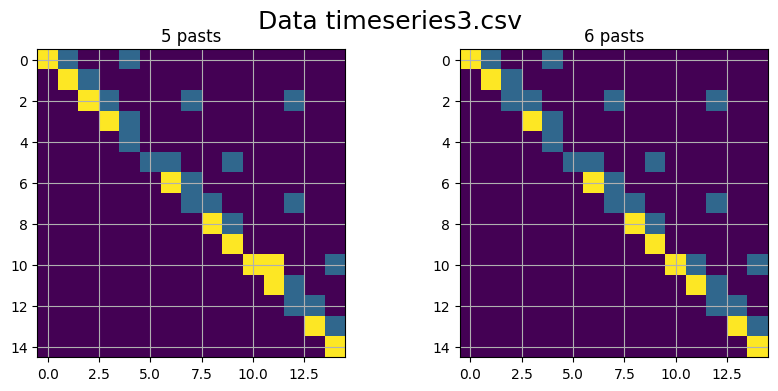

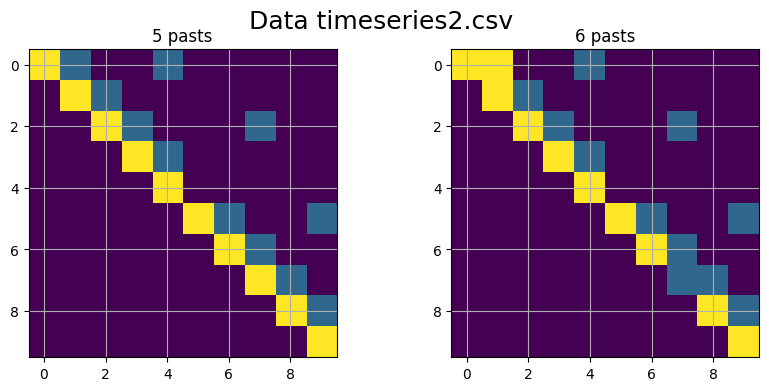

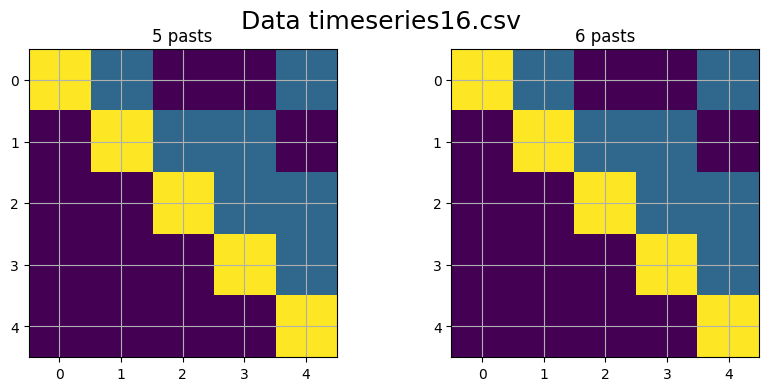

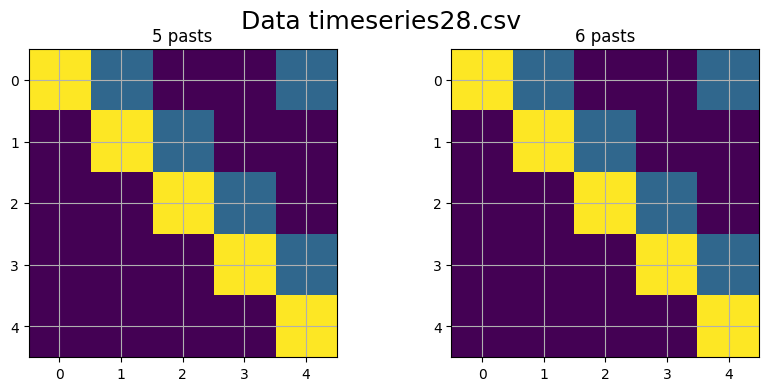

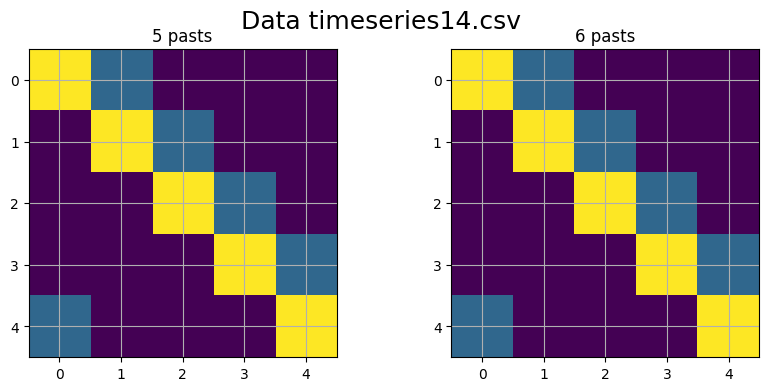

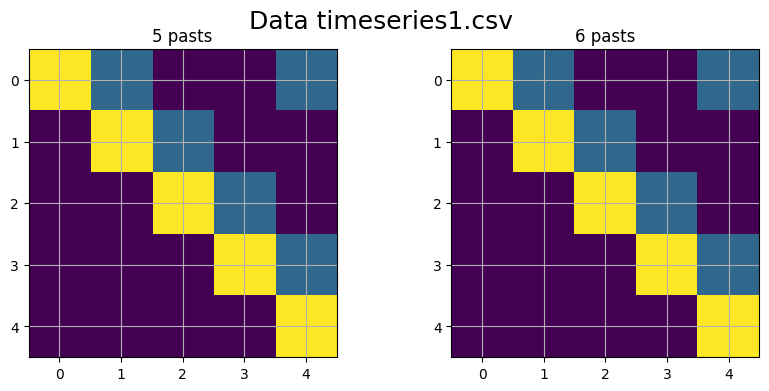

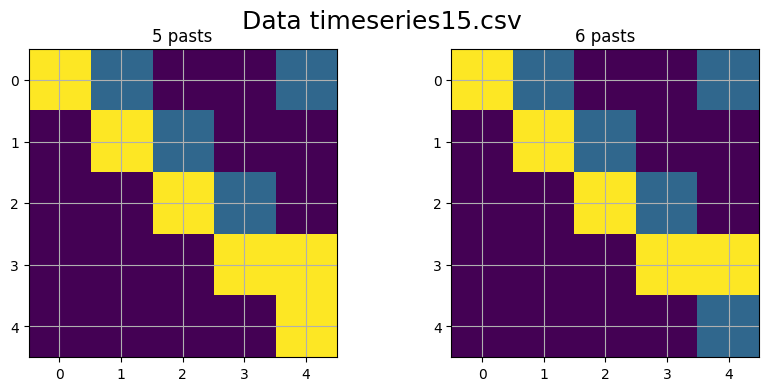

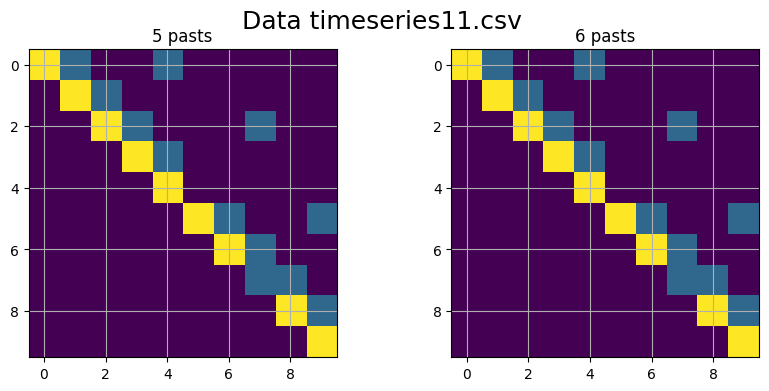

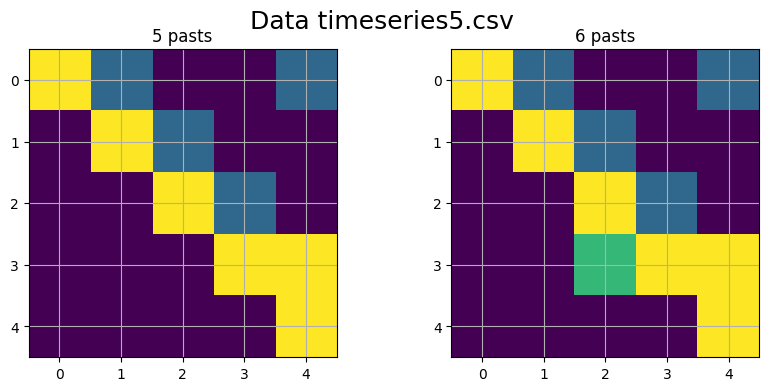

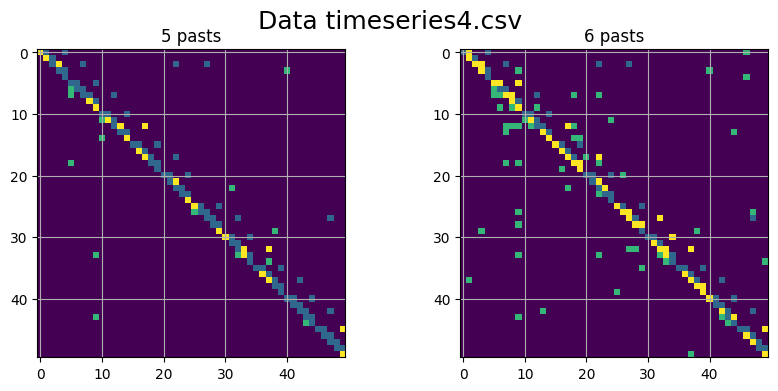

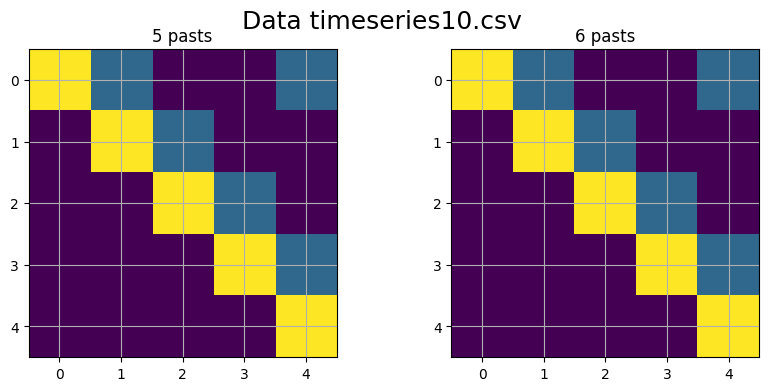

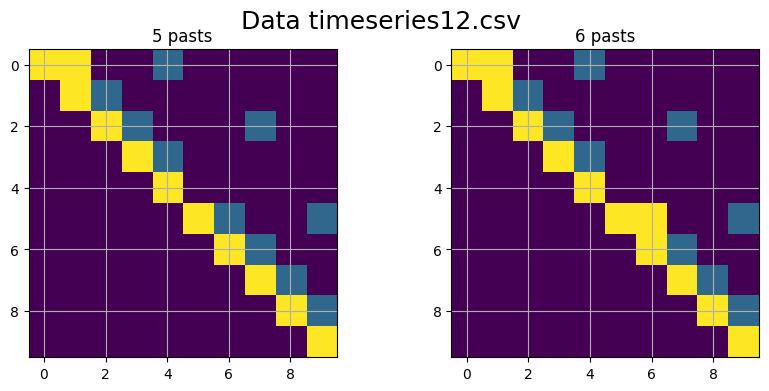

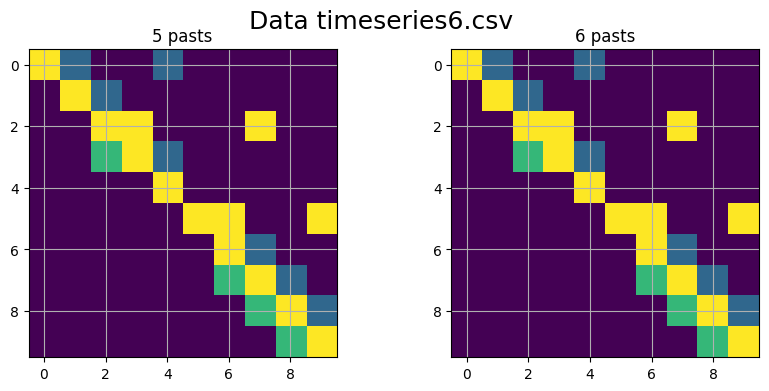

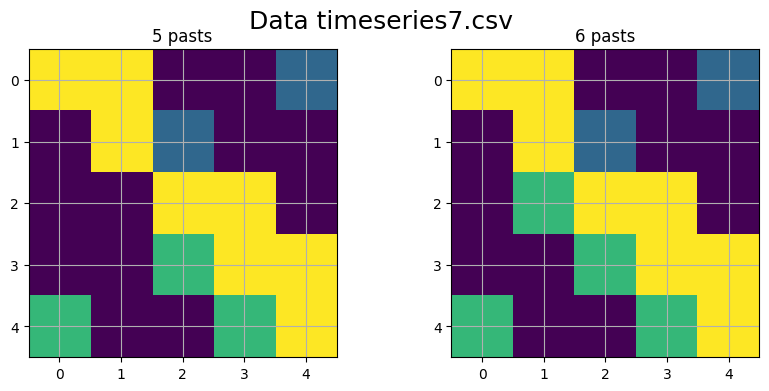

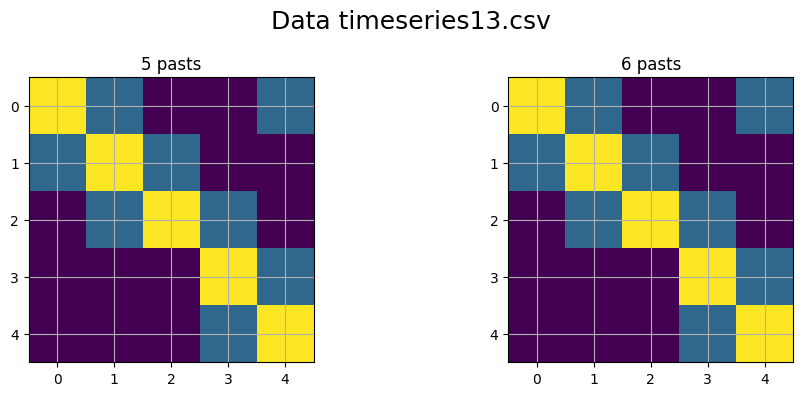

In [16]:
CONFs_new = {}
METs_new = {}
for i, keys in enumerate(INFs_new):  
    gt = GTs[keys]
    confs, mets = [], []
    fig,ax = plt.subplots(1,2,figsize=(10,4))
    for j in range(2):
        c = confusion_matrix(INFs_new[keys][j], gt)
        confs.append(c)
        mets.append(apr_metrics(c))
        
        
        ax[j].imshow(mat_func(gt, INFs_new[keys][j]))
        ax[j].set_title(f'{j+5} pasts')
        ax[j].grid()
    plt.suptitle(f'Data {names[i]}', fontsize=18)
    
    CONFs_new[keys], METs_new[keys] = confs, mets
plt.tight_layout()

In [17]:
METs_new

{'timeseries22.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries23.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries21.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries9.csv': [array([0.64      , 0.53333333, 0.8       , 0.46666667]),
  array([0.6       , 0.5       , 0.7       , 0.46666667])],
 'timeseries8.csv': [array([0.76, 1.  , 0.4 , 0.  ]),
  array([0.76, 1.  , 0.4 , 0.  ])],
 'timeseries20.csv': [array([0.8       , 0.69230769, 0.9       , 0.26666667]),
  array([0.84      , 0.875     , 0.7       , 0.06666667])],
 'timeseries24.csv': [array([0.76, 1.  , 0.4 , 0.  ]),
  array([0.72, 1.  , 0.3 , 0.  ])],
 'timeseries18.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries19.csv': [array([0.8       , 0.69230769, 0.9       , 0.26666667]),
  array([0.8       , 0.85714286, 0.6       , 0.06666667])],
 'timeseries25.csv': [array([0.76, 1.  , 0.4 , 0.  ]),
  array([0.72   

# Selections

In [18]:
N_PASTS, n_lags, n_perm = list(range(3, 10)), 1, 1000

In [19]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = ['timeseries19.csv', 'timeseries20.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries9.csv']
INFs_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.001, beta=0, simulation=True)   # 
        infs.append(inf)
        #conf = gcstar.compute_confusion_matrix(A)
        #conf_mtx.append(conf)
        
    INFs_new[names[i]] = infs
    #CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

Data timeseries19.csv with len = 2400

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries20.csv with len = 2400

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries5.csv with len = 1200

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries6.csv with len = 1200

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries7.csv with len = 5000

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries9.csv with len = 5000

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


CPU times: user 9min 39s, sys: 33 s, total: 10min 12s
Wall time: 9min 49s


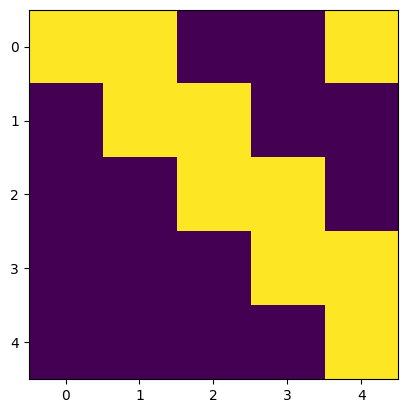

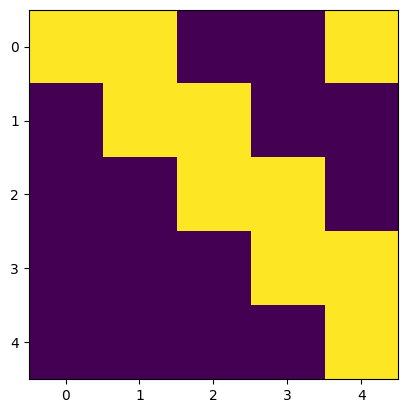

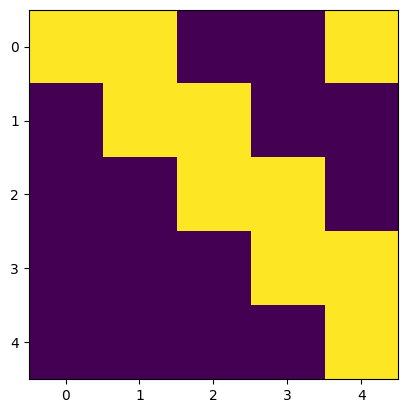

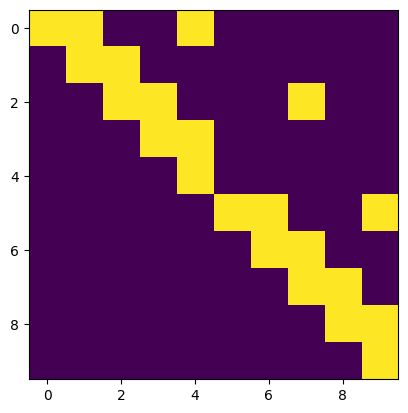

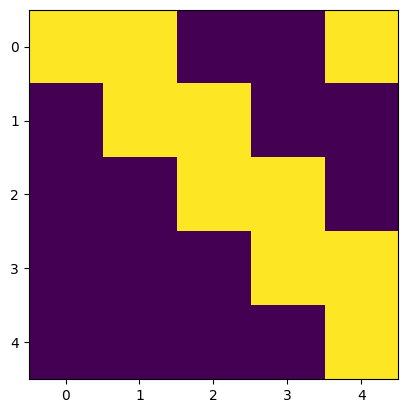

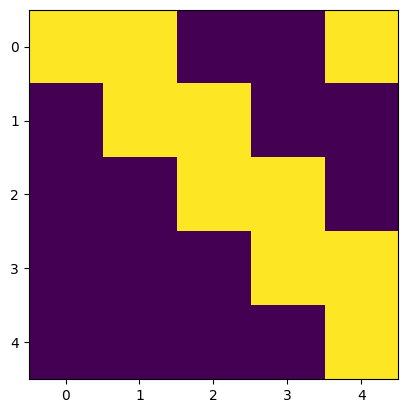

In [20]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [21]:
print(INFs_new.keys())

dict_keys(['timeseries19.csv', 'timeseries20.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries9.csv'])


In [22]:
INFs_new

{'timeseries19.csv': [array([[1.       , 0.       , 0.       , 0.       , 0.       ],
         [0.       , 1.       , 0.6342958, 0.       , 0.       ],
         [0.       , 0.6342958, 1.       , 0.       , 0.       ],
         [0.       , 0.       , 0.       , 1.       , 0.       ],
         [0.       , 0.       , 0.       , 0.       , 1.       ]]),
  array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]]),
  array([[1.        , 0.        , 0.        , 0.        , 0.        ],
         [0.47845446, 1.        , 0.63411527, 0.        , 0.        ],
         [0.        , 0.63411527, 1.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 1.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 1.        ]]),
  array([[1.        , 0.        , 0.        , 0.        , 0.        ],
         [0.47838666, 1.        , 0.6340267 , 0.        , 0.   

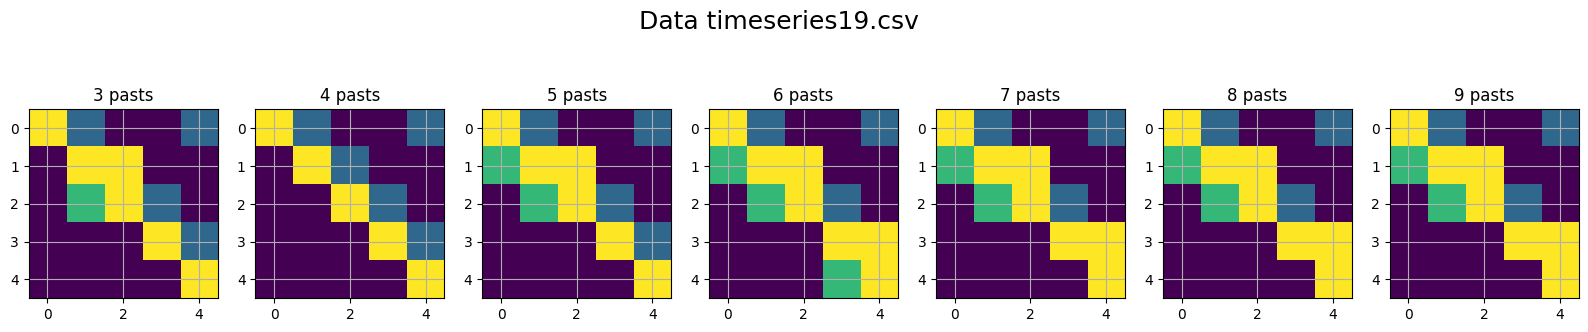

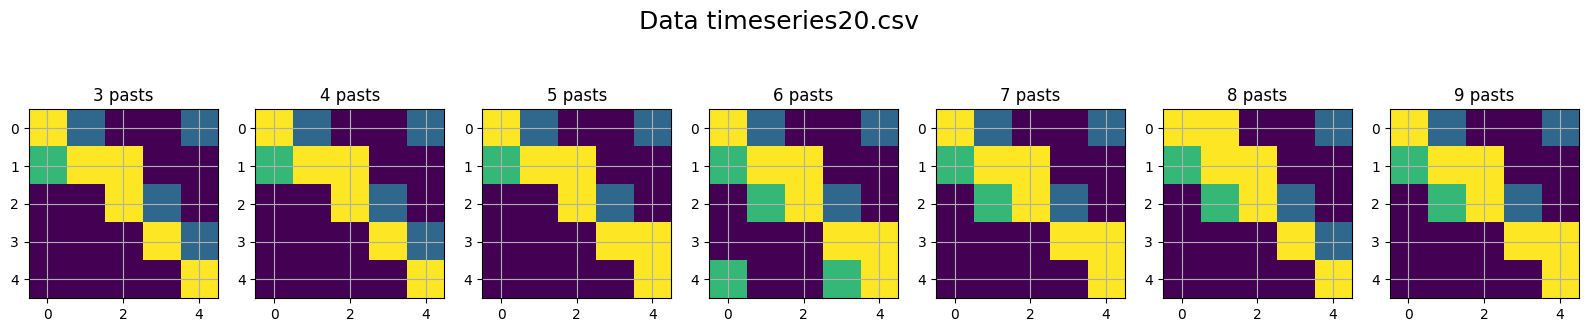

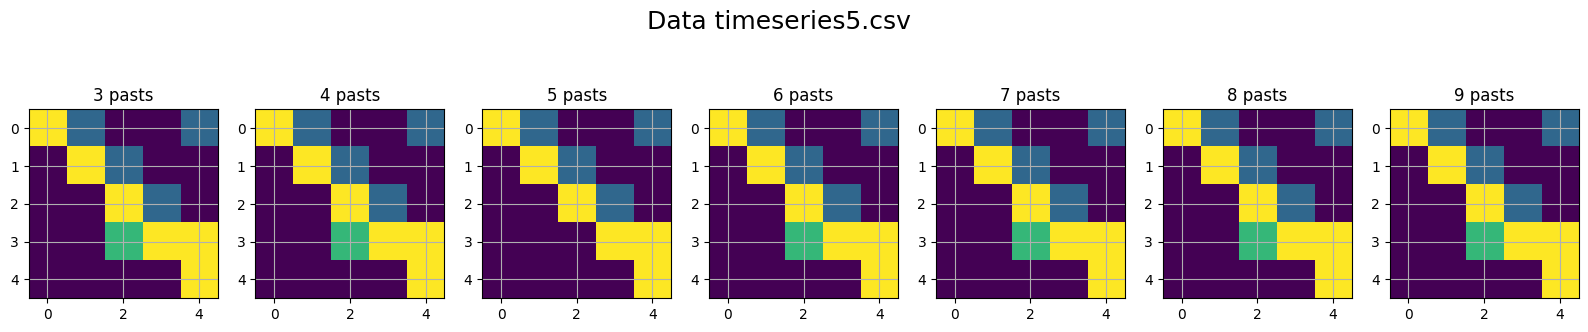

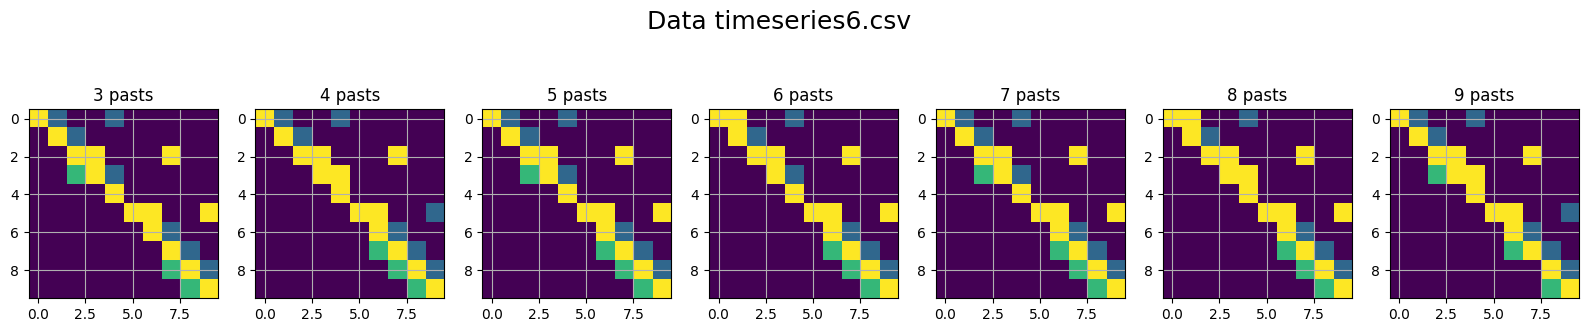

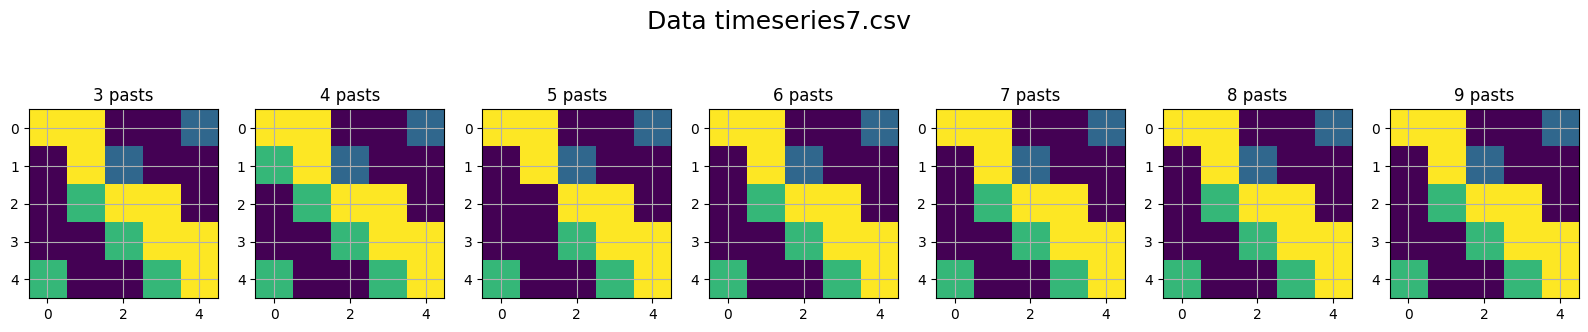

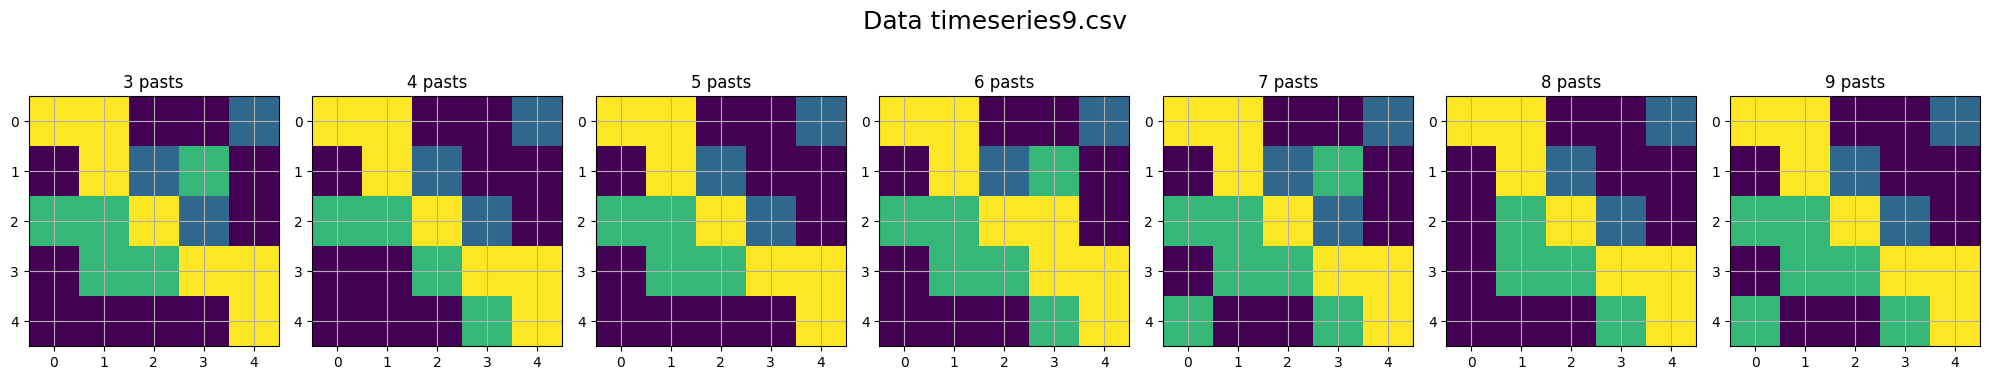

In [23]:
CONFs_new = {}
METs_new = {}
for i, keys in enumerate(INFs_new):  
    gt = GTs[keys]
    confs, mets = [], []
    fig,ax = plt.subplots(1,7,figsize=(20,4))
    for j in range(7):
        c = confusion_matrix(INFs_new[keys][j], gt)
        confs.append(c)
        mets.append(apr_metrics(c))
        
        
        ax[j].imshow(mat_func(gt, INFs_new[keys][j]))
        ax[j].set_title(f'{j+3} pasts')
        ax[j].grid()
    plt.suptitle(f'Data {names[i]}', fontsize=18)
    
    CONFs_new[keys], METs_new[keys] = confs, mets
plt.tight_layout()

In [24]:
METs_new

{'timeseries19.csv': [array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.8, 1. , 0.5, 0. ]),
  array([0.76      , 0.75      , 0.6       , 0.13333333]),
  array([0.76, 0.7 , 0.7 , 0.2 ]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333])],
 'timeseries20.csv': [array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.84      , 0.875     , 0.7       , 0.06666667]),
  array([0.72      , 0.63636364, 0.7       , 0.26666667]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333])],
 'timeseries5.csv': [array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.84, 1.  , 0.6 , 0.  ]),
  array([0.8

In [25]:
for key in METs_new:
    print(f'mean = {np.mean(METs_new[key], axis=0)}')
    print(f'std = {np.std(METs_new[key], axis=0)}')  
    print('')

mean = [0.78857143 0.80578231 0.64285714 0.11428571]
std = [0.01807016 0.09024787 0.07284314 0.0587087 ]

mean = [0.79428571 0.79414038 0.67142857 0.12380952]
std = [0.03331973 0.07575676 0.0451754  0.06598289]

mean = [0.80571429 0.87755102 0.6        0.05714286]
std = [0.01399708 0.04998959 0.         0.02332847]

mean = [0.90142857 0.81451177 0.68707483 0.04159132]
std = [0.00989743 0.02407838 0.03468721 0.0057184 ]

mean = [0.76       0.66799867 0.8        0.26666667]
std = [2.13808994e-02 2.99774291e-02 1.11022302e-16 3.56348323e-02]

mean = [0.68       0.58604491 0.71428571 0.34285714]
std = [0.0427618  0.0499783  0.03499271 0.07499055]

